# Chapter 155 — Matrix Transpose

> **Prerequisites:** Matrix representation *(ch152)*, matrix multiplication *(ch154)*
> **You will learn:**
> - What the transpose does geometrically
> - Properties: (AB)ᵀ = BᵀAᵀ, (Aᵀ)ᵀ = A
> - Symmetric matrices and why they arise everywhere in ML
> - How transpose appears in dot products, covariance, and the normal equations
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **transpose** of an m×n matrix A is the n×m matrix Aᵀ where rows and columns are swapped: `Aᵀ[i,j] = A[j,i]`.

Geometrically, the transpose is related to the *adjoint* of the transformation — intuitively, the transformation that "undoes" the geometry in the dual space. For orthogonal matrices (rotations), `Aᵀ = A⁻¹` — the transpose is the inverse.

Practically, transpose appears everywhere:
- Dot product: `u·v = uᵀv`
- Covariance matrix: `Σ = XᵀX / n`
- Normal equations: `(AᵀA)x = Aᵀb`
- Backpropagation: gradients flow through transposes

**Common misconceptions:**
- *"(AB)ᵀ = AᵀBᵀ"* — False. It reverses: `(AB)ᵀ = BᵀAᵀ`.
- *"The transpose is its own inverse."* — Only for orthogonal matrices.

---

## 2. Intuition & Mental Models

**Geometric:** The transpose reflects the matrix across its main diagonal. For a transformation A that maps column vectors, Aᵀ maps row vectors. If A maps ℝⁿ → ℝᵐ, then Aᵀ maps ℝᵐ → ℝⁿ.

**Computational:** Think of transpose as re-indexing: instead of A[row][col], you read A[col][row]. This is why column access in a C-order array can be accelerated by transposing first.

Recall from ch131 (Dot Product Intuition) that `u·v = Σᵢ uᵢvᵢ`. Written as matrix-vector product: `u·v = uᵀv` where u is treated as a row vector.

---

## 3. Visualization

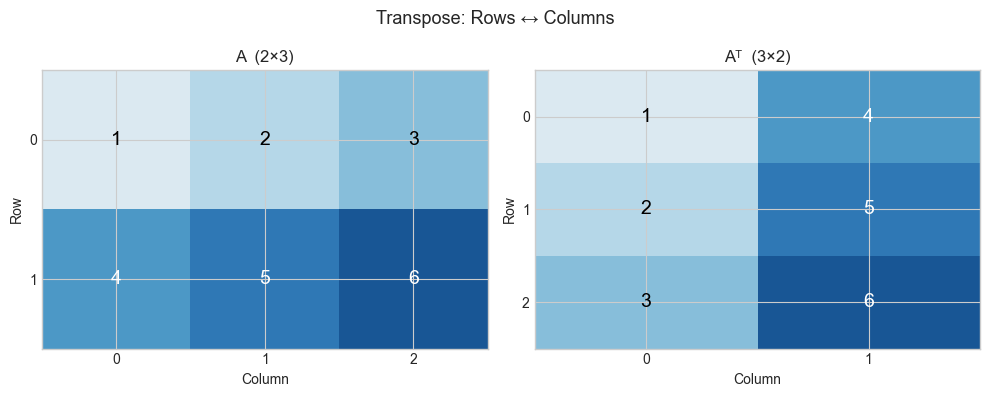

(AB)ᵀ = BᵀAᵀ  holds: True
(AB)ᵀ shape: (5, 3), BᵀAᵀ shape: (5, 3)


In [1]:
# --- Visualization: Transpose as reflection across the diagonal ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[1, 2, 3],
              [4, 5, 6]], dtype=float)   # shape: 2x3
AT = A.T                                  # shape: 3x2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [A, AT], ['A  (2×3)', 'Aᵀ  (3×2)']):
    im = ax.imshow(mat, cmap='RdBu', vmin=-7, vmax=7, aspect='auto')
    for (r, c), val in np.ndenumerate(mat):
        ax.text(c, r, f'{val:.0f}', ha='center', va='center', fontsize=14, color='white' if abs(val) > 3 else 'black')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(mat.shape[1])); ax.set_yticks(range(mat.shape[0]))
    ax.set_xlabel('Column'); ax.set_ylabel('Row')

plt.suptitle('Transpose: Rows ↔ Columns', fontsize=13)
plt.tight_layout()
plt.show()

# Key property: (AB)ᵀ = BᵀAᵀ
np.random.seed(1)
X = np.random.randn(3, 4)
Y = np.random.randn(4, 5)
lhs = (X @ Y).T
rhs = Y.T @ X.T
print(f"(AB)ᵀ = BᵀAᵀ  holds: {np.allclose(lhs, rhs)}")
print(f"(AB)ᵀ shape: {lhs.shape}, BᵀAᵀ shape: {rhs.shape}")

---

## 4. Mathematical Formulation

```
Definition: Aᵀ[i,j] = A[j,i]
Shape: A is (m×n) → Aᵀ is (n×m)

Properties:
  (Aᵀ)ᵀ = A                            [double transpose is identity]
  (A + B)ᵀ = Aᵀ + Bᵀ                  [transpose distributes over addition]
  (αA)ᵀ = αAᵀ                          [scalar factors pass through]
  (AB)ᵀ = BᵀAᵀ                         [REVERSAL — not AᵀBᵀ]
  (ABC)ᵀ = CᵀBᵀAᵀ                      [full reversal for long products]

Symmetric matrix: A = Aᵀ   (requires A to be square)
  AᵀA is ALWAYS symmetric:  (AᵀA)ᵀ = Aᵀ(Aᵀ)ᵀ = AᵀA  ✓
```

In [2]:
# --- Implementation: Transpose operations and symmetric matrices ---
import numpy as np

def my_transpose(A):
    """
    Compute matrix transpose without using .T.

    Args:
        A: 2D numpy array, shape (m, n)
    Returns:
        2D numpy array, shape (n, m)
    """
    m, n = A.shape
    AT = np.empty((n, m), dtype=A.dtype)
    for i in range(m):
        for j in range(n):
            AT[j, i] = A[i, j]
    return AT

A = np.array([[1,2,3],[4,5,6]], dtype=float)
print(f"My transpose:\n{my_transpose(A)}")
print(f"NumPy .T:\n{A.T}")
print(f"Match: {np.allclose(my_transpose(A), A.T)}")
print()

# AᵀA is always symmetric
np.random.seed(3)
M = np.random.randn(5, 3)
S = M.T @ M   # 3x3 symmetric matrix
print(f"M.T @ M symmetric: {np.allclose(S, S.T)}")
print(f"Shape: {M.shape} → {S.shape}")
print()

# Gram matrix: used in kernel methods, style transfer, etc.
print("Gram matrix (covariance-like):")
X = np.random.randn(4, 100)  # 4 features, 100 samples
cov = X @ X.T / 100          # 4x4 covariance matrix
print(f"Cov shape: {cov.shape}, symmetric: {np.allclose(cov, cov.T)}")

My transpose:
[[1. 4.]
 [2. 5.]
 [3. 6.]]
NumPy .T:
[[1. 4.]
 [2. 5.]
 [3. 6.]]
Match: True

M.T @ M symmetric: True
Shape: (5, 3) → (3, 3)

Gram matrix (covariance-like):
Cov shape: (4, 4), symmetric: True


---

## 6. Experiments

Fitted: slope=1.9227, intercept=1.4146
True:   slope=2.0000, intercept=1.0000


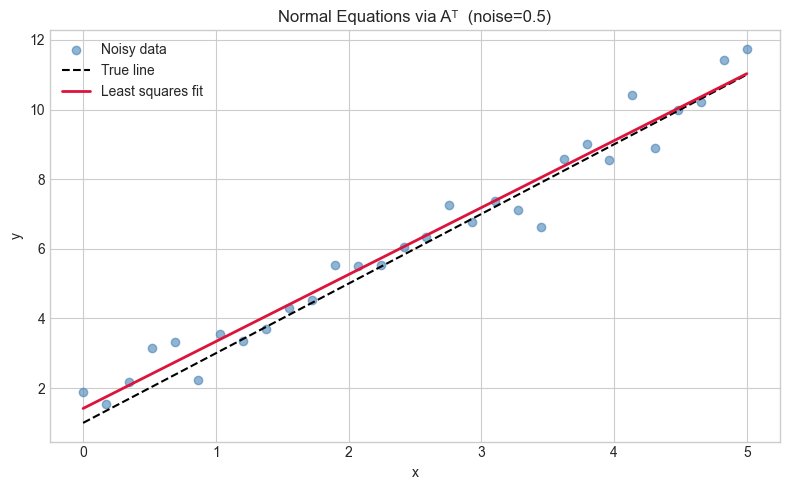

In [3]:
# --- Experiment: Transpose and the normal equations ---
# Hypothesis: The least-squares solution x* = (AᵀA)⁻¹Aᵀb minimizes ||Ax-b||²
# Try changing: NOISE_LEVEL
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

NOISE_LEVEL = 0.5   # <-- try 0.1, 1.0, 3.0

np.random.seed(0)
# True line: y = 2x + 1
x_data = np.linspace(0, 5, 30)
y_true = 2 * x_data + 1
y_noisy = y_true + NOISE_LEVEL * np.random.randn(len(x_data))

# Design matrix A: [x, 1] for each sample
A = np.column_stack([x_data, np.ones(len(x_data))])  # (30, 2)
b = y_noisy                                            # (30,)

# Normal equations: x* = (AᵀA)⁻¹Aᵀb
ATA = A.T @ A                # (2, 2)
ATb = A.T @ b                # (2,)
x_star = np.linalg.solve(ATA, ATb)   # solve rather than invert (numerically better)

print(f"Fitted: slope={x_star[0]:.4f}, intercept={x_star[1]:.4f}")
print(f"True:   slope=2.0000, intercept=1.0000")

plt.figure(figsize=(8,5))
plt.scatter(x_data, y_noisy, color='steelblue', alpha=0.6, label='Noisy data')
plt.plot(x_data, y_true, 'k--', label='True line')
plt.plot(x_data, A @ x_star, 'crimson', lw=2, label='Least squares fit')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Normal Equations via Aᵀ  (noise={NOISE_LEVEL})')
plt.tight_layout(); plt.show()

---

## 7. Exercises

**Easy 1.** Compute by hand: transpose `[[1,2,3],[4,5,6]]`. What is the shape before and after?

**Easy 2.** Is `[[1,2],[2,5]]` symmetric? Is `[[0,1],[-1,0]]` symmetric? What is the latter called?

**Medium 1.** Prove that for any matrix A, `A + Aᵀ` is always symmetric and `A - Aᵀ` is always skew-symmetric (equal to its own negated transpose). Verify with a random 4×4 matrix.

**Medium 2.** Write a function `is_orthogonal(A, tol=1e-9)` that returns True if `A.T @ A ≈ I`. Test on: (a) a random matrix, (b) a rotation matrix, (c) a reflection matrix.

**Hard.** Show that any matrix A can be decomposed as A = S + K where S is symmetric and K is skew-symmetric. Give the formulas for S and K in terms of A and Aᵀ. Implement and verify.

---

## 8. Mini Project

Max difference from np.cov: 1.39e-17


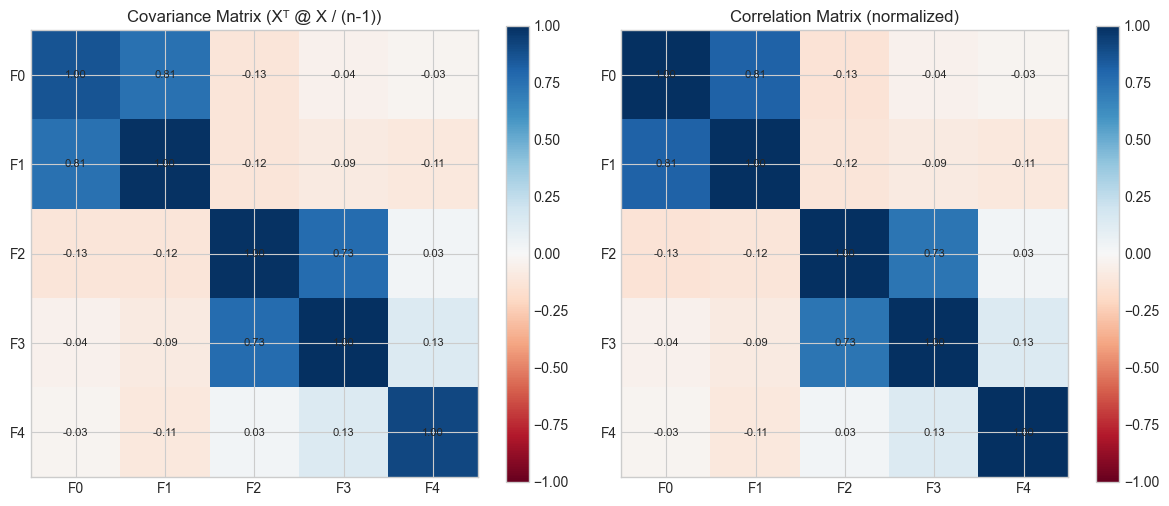

In [4]:
# --- Mini Project: Covariance matrix via transpose ---
# Problem: Given a dataset, compute the covariance matrix using only
# matrix operations (no loops, no np.cov call until verification).
# Then visualize which features are most correlated.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
# Generate correlated data: 5 features, 200 samples
# True covariance structure has correlations between features 0-1, 2-3
L = np.array([[1,0,0,0,0],[0.8,0.6,0,0,0],[0,0,1,0,0],[0,0,0.7,0.71,0],[0,0,0,0,1]])
data = (L @ np.random.randn(5, 200)).T   # (200, 5)

# Step 1: Center the data (subtract column means)
means = data.mean(axis=0)          # shape (5,)
X_centered = data - means          # broadcasting: subtract mean from each row

# Step 2: Compute covariance matrix C = (1/n) * Xᵀ @ X  (each feature is a row)
n = data.shape[0]
C = (X_centered.T @ X_centered) / (n - 1)   # unbiased estimate

# Verify against numpy
C_numpy = np.cov(data.T)
print(f"Max difference from np.cov: {np.max(np.abs(C - C_numpy)):.2e}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
feature_names = ['F0','F1','F2','F3','F4']

# Covariance matrix
im1 = axes[0].imshow(C, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Covariance Matrix (Xᵀ @ X / (n-1))')
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))
axes[0].set_xticklabels(feature_names); axes[0].set_yticklabels(feature_names)
plt.colorbar(im1, ax=axes[0])

# Correlation matrix (normalize by std)
std = np.sqrt(np.diag(C))
corr = C / np.outer(std, std)
im2 = axes[1].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Correlation Matrix (normalized)')
axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5))
axes[1].set_xticklabels(feature_names); axes[1].set_yticklabels(feature_names)
plt.colorbar(im2, ax=axes[1])
for ax in axes:
    for (r,c), val in np.ndenumerate(corr):
        ax.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout(); plt.show()

---

## 9. Chapter Summary & Connections

- Transpose flips rows and columns: `Aᵀ[i,j] = A[j,i]`.
- Key reversal rule: `(AB)ᵀ = BᵀAᵀ` — order reverses.
- `AᵀA` is always symmetric and positive semi-definite — it is the covariance structure of A.
- The normal equations `(AᵀA)x = Aᵀb` solve least squares *(reappears in ch181 — Linear Regression via Matrix Algebra)*.

**Backward connection:** The dot product `u·v = uᵀv` connects to ch131 — we are just writing it in matrix notation.

**Forward connections:**
- In ch168 (Projection Matrices), the formula `P = A(AᵀA)⁻¹Aᵀ` will use transpose in a deep geometric way.
- In ch176 (Matrix Calculus), the gradient of `||Ax-b||²` with respect to x is `2Aᵀ(Ax-b)` — transpose appears in every gradient.